# 02_data_exploration
## 1. 데이터 로드

In [4]:
import pandas as pd
from pathlib import Path

# 프로젝트 루트 기준 경로
csv_path = Path().resolve().parent / "data" / "processed" / "processed_data.csv"
print(csv_path)  # 실제 경로 확인

df = pd.read_csv(csv_path, parse_dates=["datetime"])
df.set_index("datetime", inplace=True)

/Users/hyunkyung/Desktop/Projects/EuropeEnergyTradingAnalysis/data/processed/processed_data.csv


## 2. Load vs Forecast Load

In [5]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose


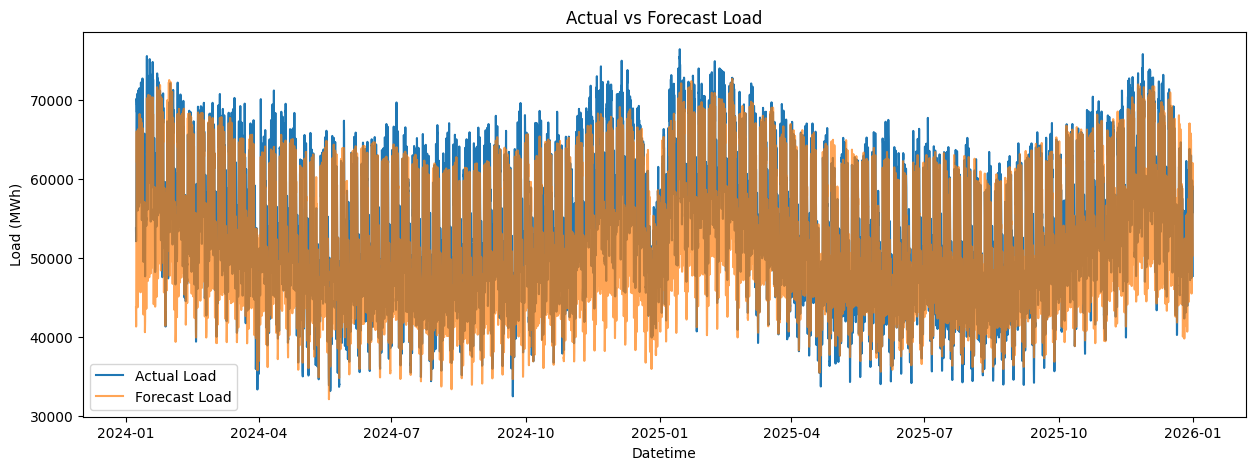

In [6]:
plt.figure(figsize=(15,5))
plt.plot(df["actual_load"], label="Actual Load")
plt.plot(df["forecast_load"], label="Forecast Load", alpha=0.7)
plt.title("Actual vs Forecast Load")
plt.xlabel("Datetime")
plt.ylabel("Load (MWh)")
plt.legend()
plt.show()

## 3. 재생에너지 분석

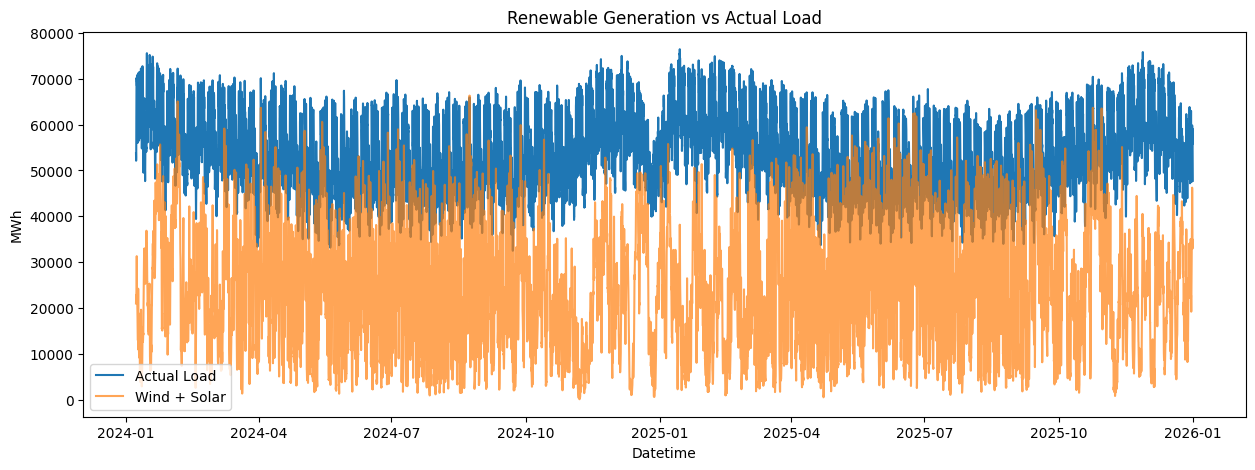

In [7]:
plt.figure(figsize=(15,5))
plt.plot(df["actual_load"], label="Actual Load")
plt.plot(df["wind_generation"] + df["solar"], label="Wind + Solar", alpha=0.7)
plt.title("Renewable Generation vs Actual Load")
plt.xlabel("Datetime")
plt.ylabel("MWh")
plt.legend()
plt.show()

## 4. 시계열 정상성 확인
- ADF, KPSS 테스트
- 차분 후 정상화

In [8]:
# ADF
result = adfuller(df['actual_load'].dropna())
print('ADF Statistic:', result[0], 'p-value:', result[1])

ADF Statistic: -12.44688975295571 p-value: 3.647730431411394e-23


In [9]:
# 1차 차분
df['actual_load_diff'] = df['actual_load'] - df['actual_load'].shift(1)

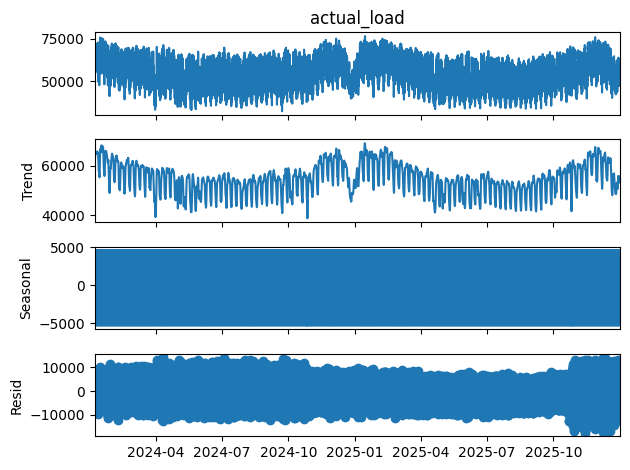

In [10]:
# 시계열 분해
decomposition = seasonal_decompose(df['actual_load'], model='additive', period=24)
decomposition.plot()
plt.show()